![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 3. Circuits and Compact Models

 ## 0.1 Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import logging
import sys
from functools import partial
from pprint import pprint

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from numpy.fft import fft2, fftfreq, fftshift, ifft2
from rich.logging import RichHandler
from scipy import constants
from sklearn.linear_model import LinearRegression
from tqdm.notebook import trange
from scipy.constants import c as c0

import gplugins.sax as gs
import gplugins.tidy3d as gt
from gplugins.common.config import PATH

logger = logging.getLogger()
logger.removeHandler(sys.stderr)
logging.basicConfig(level="WARNING", datefmt="[%X]", handlers=[RichHandler()])

/tmp/ipykernel_1100/616826865.py:17: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 0.2 Compact Models for simulations

### 0.2.1. Waveguide compact model (Lab1. LO4)

We start from the waveguide's effective index second degree polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Or from the parameters derived from the polynomial coefficients: 
 
$$
n_\mathrm{eff}(\lambda_0) = n_1~ ;~ n_g(\lambda_0) = n_1 - n_2\,\lambda_0~;~ D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

The transmmission through the waveguide should be modeled as: 

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$
With  
$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

We are going to use [SAX](https://pypi.org/project/sax/), a scatter parameter circuit simulator, to implement simulations in the frequency (wavelength) domain. The following cell demonstrates how to define the most basic component transfer function: 

In [2]:
# The model should be a Python function that takes as input the relevant parameters
# (e.g., wavelength, effective index, length, loss) and returns a SAX SDict representing
# the waveguide's S-parameters.
# Parameters:
# wl: Wavelength to simulate (um)
# wl0: Reference wavelength - where you calculated the group index and dispersion (um))
# neff: Effective index at the reference wavelength (au)
# ng: Group index (au)
# length: Length of the waveguide in micrometers (um)
# loss: Propagation loss in dB/um (Experimental value)
# D: Dispersion parameter (s^2/m)
def waveguide(wl=1.55, wl0=1.55, neff=1.6072, ng=2.0, length=10.0, loss=0.0, D=0) -> sax.SDict:
    dwl = wl - wl0
    n1 = neff
    n2 = (n1-ng)/wl0
    n3 = -D*c0/(2*wl0)
    neff = n1 + n2*dwl + n3*dwl**2
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

### 0.2.2. Coupler compact model (Lab2 LO6)

We can start with the ideal coupler transfer function. You can then update your model with the parameters you found in your Laboratory 2. The model we are going to implement does not take into account if the coupler is an MMI or a Directional Coupler, it just use as parameters the coupling coefficient to calculate the output power at each port. 

$$
\begin{pmatrix}
E_{o1}\\
E_{o2}
\end{pmatrix}
=
\begin{pmatrix}
\sqrt{1-K} & -\mathrm{j}\sqrt{K}\\
-\mathrm{j}\sqrt{K} & \sqrt{1-K}
\end{pmatrix}
\begin{pmatrix}
E_{i1}\\
E_{i2}
\end{pmatrix}
$$

In [3]:
# Coupler Model
# We define again the Python function for the coupler compact model.
# Parameters:
# coupling: Coupling coefficient (between 0 and 1)
# You MUST update the model with the parameters you found in your Laboratory 2: 
# Excess loss, actual phase shift.
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    # The coupler is a reciprocal device, so we use sax.reciprocal to create the SDict
    # (reciprocal device means it behaves the same way in both directions)
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict


## LO.1. Mach - Zehnder Interferometer

### 1.a. MZI Circuit Model. Perfectly balanced MZI

Using SAX library, we can now define the components, connections and models needed to build our circuit. Let's start with the MZI: 

<img src="mzi.png" alt="mzi circuit" width="600">

We will need two couplers and two waveguides: 


In [4]:
# MZI Circuit
# We define the instances, connections and ports for the MZI circuit using SAX.
# The MZI has two couplers and two waveguides.

mzi, info = sax.circuit(
    netlist={
        # Define instances of couplers and waveguides
        "instances": {
            "coup_E": "coupler",
            "wvg_N": "waveguide",
            "wvg_S": "waveguide",
            "coup_W": "coupler",
        },

        # Define connections between the instances
        "connections": {
            "coup_E,out0": "wvg_S,in0",
            "wvg_S,out0": "coup_W,in0",
            "coup_E,out1": "wvg_N,in0",
            "wvg_N,out0": "coup_W,in1",
        },

        # Define the external ports of the MZI circuit
        "ports": {
            "in0": "coup_E,in0",
            "in1": "coup_E,in1",
            "out0": "coup_W,out0",
            "out1": "coup_W,out1",
        },
    },

    # Models used in the circuit
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


[08:18:49] WARNING  WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but ]8;id=237435;file:///home/lidia/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py\xla_bridge.py]8;;\:]8;id=513615;file:///home/lidia/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py#864\864]8;;\
                    a CUDA-enabled jaxlib is not installed. Falling back to cpu.                                   

Using this circuit model, it is possible now to perform simulations to obtain the MZI response:

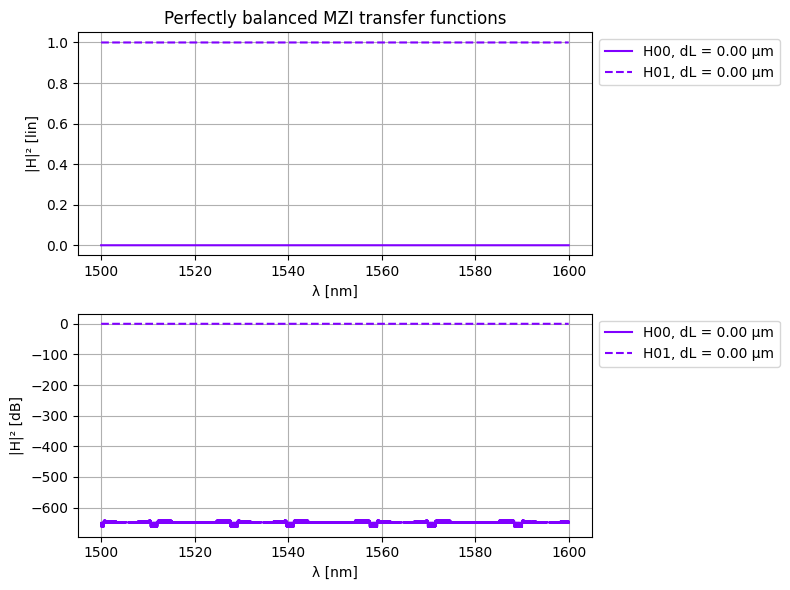

In [5]:
# Learning outcome #1a – Perfectly balanced MZI

# Wavelengths to simulate
# wvl [1500-1600] step 0.001 nm
# wl is in micrometers, so 1500 nm = 1.50 um and 1600 nm = 1.60 um
wl = jnp.linspace(1.50, 1.60, 100001)

# Perfectly balanced MZI
# dL = 0 um
delta_l_v = np.array([0.0])

# Base length of both arms
l_base = 10.0

# Coupling coefficients
Kin = 0.5
Kout = 0.5

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i, delta_l in enumerate(delta_l_v):

    # Simulate perfectly balanced MZI
    # South arm length = l_base
    # North arm length = l_base + delta_l = l_base
    mzi_test = mzi(
        wl=wl,
        coup_E={"coupling": Kin},
        coup_W={"coupling": Kout},
        wvg_S={"length": l_base},
        wvg_N={"length": l_base + delta_l},
    )

    # Extract transfer functions
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    # Linear transmission
    H00_lin = np.abs(H00) ** 2
    H01_lin = np.abs(H01) ** 2

    # dB transmission
    H00_dB = 20.0 * jnp.log10(H00_lin)
    H01_dB = 20.0 * jnp.log10(H01_lin)

    # Plot linear transfer functions
    ax[0].plot(
        wl * 1e3,
        H00_lin,
        linestyle="-",
        color=color[i],
        label=f"H00, dL = {delta_l:.2f} µm",
    )

    ax[0].plot(
        wl * 1e3,
        H01_lin,
        linestyle="--",
        color=color[i],
        label=f"H01, dL = {delta_l:.2f} µm",
    )

    # Plot dB transfer functions
    ax[1].plot(
        wl * 1e3,
        H00_dB,
        linestyle="-",
        color=color[i],
        label=f"H00, dL = {delta_l:.2f} µm",
    )

    ax[1].plot(
        wl * 1e3,
        H01_dB,
        linestyle="--",
        color=color[i],
        label=f"H01, dL = {delta_l:.2f} µm",
    )

# Plot formatting
for i in range(0, 2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc="upper left", bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|² [lin]")
ax[1].set_ylabel("|H|² [dB]")

ax[0].set_title("Perfectly balanced MZI transfer functions")

plt.tight_layout()
plt.show()

## 1.b MZI Circuit Model. Unbalanced MZI

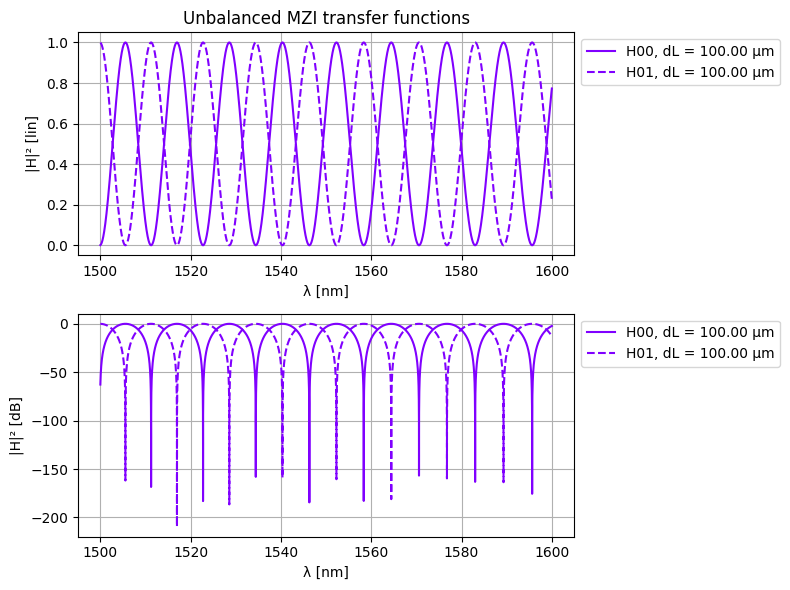

FSR calculation:
lambda0 = 1.55 um
ng = 2.00
dL = 100.00 um
FSR = 0.012013 um
FSR = 12.013 nm


In [6]:
# Learning outcome #1b – Unbalanced MZI

# Wavelengths to simulate
# wvl [1500-1600] step 0.001 nm
# wl is in micrometers, so 1500 nm = 1.50 um and 1600 nm = 1.60 um
wl = jnp.linspace(1.50, 1.60, 100001)

# Length difference between MZI arms
# dL = 100 um
delta_l_v = np.array([100.0])

# Base length of one arm
l_base = 10.0

# Coupling coefficients
Kin = 0.5
Kout = 0.5

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i, delta_l in enumerate(delta_l_v):

    # Simulate MZI with given length difference
    # South arm length = l_base
    # North arm length = l_base + delta_l
    mzi_test = mzi(
        wl=wl,
        coup_E={"coupling": Kin},
        coup_W={"coupling": Kout},
        wvg_S={"length": l_base},
        wvg_N={"length": l_base + delta_l},
    )

    # Extract transfer functions
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    # Linear transmission
    H00_lin = np.abs(H00) ** 2
    H01_lin = np.abs(H01) ** 2

    # dB transmission
    H00_dB = 20.0 * jnp.log10(H00_lin)
    H01_dB = 20.0 * jnp.log10(H01_lin)

    # Plot linear transfer functions
    ax[0].plot(
        wl * 1e3,
        H00_lin,
        linestyle="-",
        color=color[i],
        label=f"H00, dL = {delta_l:.2f} µm",
    )

    ax[0].plot(
        wl * 1e3,
        H01_lin,
        linestyle="--",
        color=color[i],
        label=f"H01, dL = {delta_l:.2f} µm",
    )

    # Plot dB transfer functions
    ax[1].plot(
        wl * 1e3,
        H00_dB,
        linestyle="-",
        color=color[i],
        label=f"H00, dL = {delta_l:.2f} µm",
    )

    ax[1].plot(
        wl * 1e3,
        H01_dB,
        linestyle="--",
        color=color[i],
        label=f"H01, dL = {delta_l:.2f} µm",
    )

# Plot formatting
for i in range(0, 2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc="upper left", bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|² [lin]")
ax[1].set_ylabel("|H|² [dB]")

ax[0].set_title("Unbalanced MZI transfer functions")

plt.tight_layout()
plt.show()


# FSR calculation
lambda0 = 1.55       # central wavelength in um
ng = 2.0             # group index used in the waveguide model
delta_l = 100.0      # length difference in um

FSR_um = lambda0**2 / (ng * delta_l)
FSR_nm = FSR_um * 1e3

print("FSR calculation:")
print(f"lambda0 = {lambda0:.2f} um")
print(f"ng = {ng:.2f}")
print(f"dL = {delta_l:.2f} um")
print(f"FSR = {FSR_um:.6f} um")
print(f"FSR = {FSR_nm:.3f} nm")

The resulting interference pattern allows us to determine the **free spectral range** (FSR). By locating two adjacent notches in the transfer function, the difference between their wavelengths gives the FSR, which satisfies:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,\Delta L}
$$

You can use this code section with certain variations for LO1a,1b,2 and 3.

## LO.2. MZI Design

MZI design:
lambda0 = 1.55 um
Target FSR = 2.00 nm
ng = 2.00
Calculated dL = 600.625 um


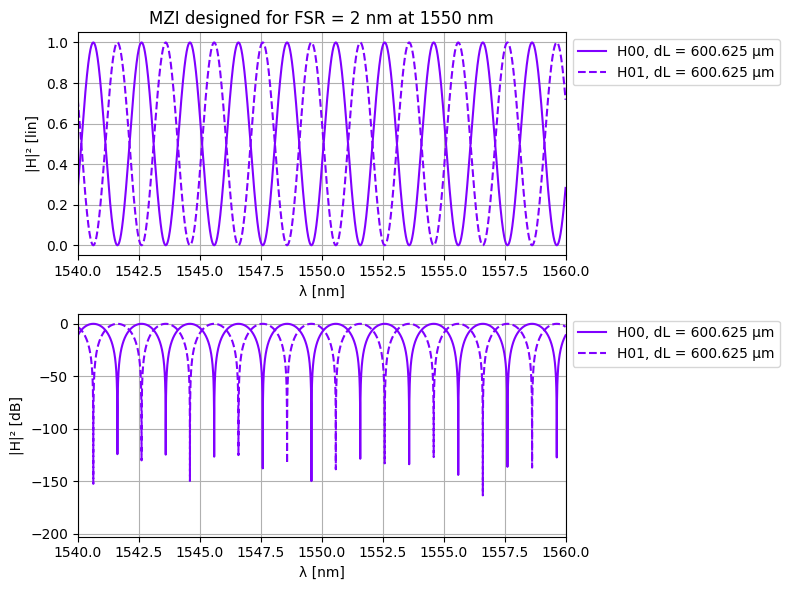

FSR check:
Calculated dL = 600.625 um
FSR = 2.000 nm


In [7]:
# ============================================================
# Learning outcome #2 – MZI Design
# Design a MZI with FSR = 10 nm at 1550 nm
# ============================================================

# Wavelengths to simulate
# wvl [1500-1600] step 0.001 nm
# wl is in micrometers
wl = jnp.linspace(1.50, 1.60, 100001)

# ------------------------------------------------------------
# Design parameters
# ------------------------------------------------------------

lambda0 = 1.55        # central wavelength in um = 1550 nm
FSR_nm = 2.0         # target FSR in nm
FSR_um = FSR_nm * 1e-3  # convert FSR from nm to um

ng = 2.0              # group index from the waveguide model

# Formula:
# FSR = lambda0^2 / (ng * dL)
# Therefore:
# dL = lambda0^2 / (ng * FSR)

delta_l = lambda0**2 / (ng * FSR_um)

# Put dL into an array, as in the previous code
delta_l_v = np.array([delta_l])

# Base length of one arm
l_base = 10.0

# Coupling coefficients
Ka = 0.5
Kb = 0.5

print("MZI design:")
print(f"lambda0 = {lambda0:.2f} um")
print(f"Target FSR = {FSR_nm:.2f} nm")
print(f"ng = {ng:.2f}")
print(f"Calculated dL = {delta_l:.3f} um")


# ============================================================
# Simulation
# ============================================================

mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

for i, delta_l in enumerate(delta_l_v):

    # Simulate the designed MZI
    # South arm length = l_base
    # North arm length = l_base + delta_l
    mzi_test = mzi(
        wl=wl,
        coup_E={"coupling": Ka},
        coup_W={"coupling": Kb},
        wvg_S={"length": l_base},
        wvg_N={"length": l_base + delta_l},
    )

    # Extract transfer functions
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    # Linear transmission
    H00_lin = np.abs(H00) ** 2
    H01_lin = np.abs(H01) ** 2

    # dB transmission
    H00_dB = 20.0 * jnp.log10(H00_lin)
    H01_dB = 20.0 * jnp.log10(H01_lin)

    # Plot linear transfer functions
    ax[0].plot(
        wl * 1e3,
        H00_lin,
        linestyle="-",
        color=color[i],
        label=f"H00, dL = {delta_l:.3f} µm",
    )

    ax[0].plot(
        wl * 1e3,
        H01_lin,
        linestyle="--",
        color=color[i],
        label=f"H01, dL = {delta_l:.3f} µm",
    )

    # Plot dB transfer functions
    ax[1].plot(
        wl * 1e3,
        H00_dB,
        linestyle="-",
        color=color[i],
        label=f"H00, dL = {delta_l:.3f} µm",
    )

    ax[1].plot(
        wl * 1e3,
        H01_dB,
        linestyle="--",
        color=color[i],
        label=f"H01, dL = {delta_l:.3f} µm",
    )

# Plot formatting
for i in range(0, 2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc="upper left", bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|² [lin]")
ax[1].set_ylabel("|H|² [dB]")

ax[0].set_title("MZI designed for FSR = 2 nm at 1550 nm")
ax[0].set_xlim(1540, 1560)
ax[1].set_xlim(1540, 1560)
plt.tight_layout()
plt.show()


# ============================================================
# Check FSR
# ============================================================

FSR_check_um = lambda0**2 / (ng * delta_l)
FSR_check_nm = FSR_check_um * 1e3

print("FSR check:")
print(f"Calculated dL = {delta_l:.3f} um")
print(f"FSR = {FSR_check_nm:.3f} nm")

## LO.3. Delay imbalance with loss

Text(0, 0.5, '|H|^2 [dB]')

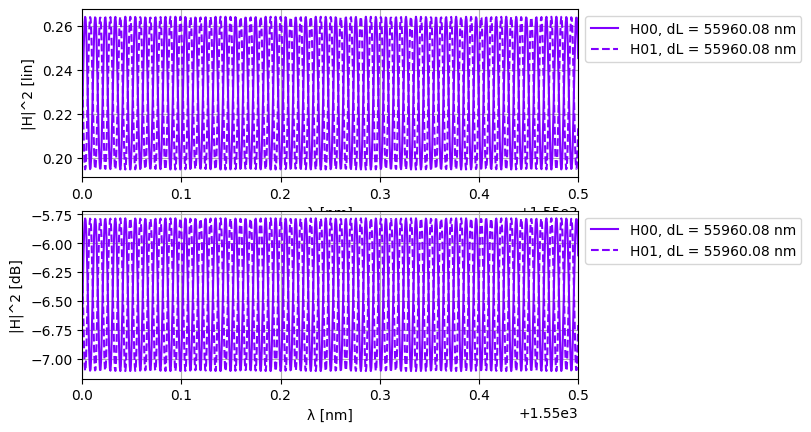

In [8]:
# Wavelengths to simulate
wl = jnp.linspace(1.55, 1.5505, 1001)
 
# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([55960.0840224255,])
l_base = 1000.0
 
# Testbench
mzi_test = []
 
n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))
 
fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base, "loss" : 0.0004, "ng": 4.25, "neff":2.38},
                    wvg_N={"length": l_base+delta_l, "loss" : 0.0004, "ng": 4.25, "neff":2.38})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]
 
    H00_dB = 10.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 10.0*jnp.log10(np.abs(H01) ** 2)
 
    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")
 
    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")
 
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].set_xlim(1550, 1550.5)
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
 
ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

Text(0, 0.5, '|H|^2 [dB]')

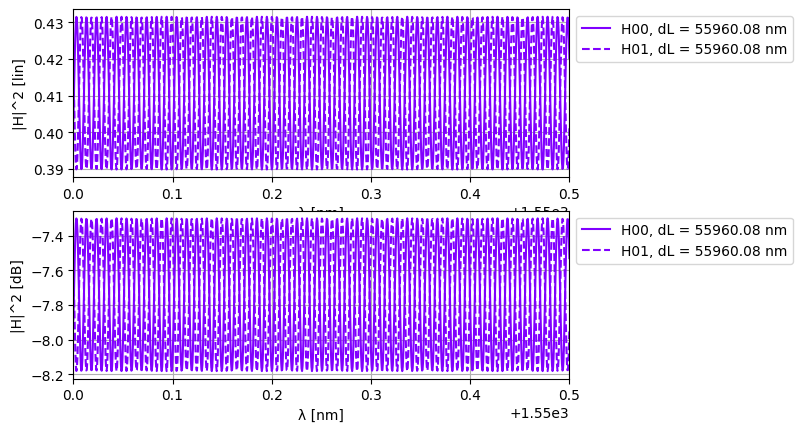

In [9]:
# Wavelengths to simulate
wl = jnp.linspace(1.55, 1.5505, 1001)
 
# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([55960.0840224255,])
l_base = 1000.0
 
# Testbench
mzi_test = []
 
n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))
 
fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base, "loss" : 0.0004, "ng": 4.25, "neff":2.38},
                    wvg_N={"length": l_base+delta_l, "loss" : 0.0004, "ng": 4.25, "neff":2.38},
                    coup_E={"coupling": 0.1})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]
 
    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)
 
    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")
 
    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")
 
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].set_xlim(1550, 1550.5)
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
 
ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

## LO.4. Ring Resonators.

### 1.1. Ring Resonator Circuit Models

We can implement two different variations for the Ring Resonator. The simple ring that consist of a coupler connected with a waveguide (ring_ap), and the double bus ring that needs an extra coupler and the corresponding waveguides to make connections between them (ring_2bus): 

<img src="rings.png" alt="mzi circuit" width="600">


#### 1.1.1. Ring coupled to a single waveguide

We define one circuit per design variation. 

In [10]:
ring_ap, info = sax.circuit(
    netlist={
        "instances": {
            "coup": "coupler",
            "wvg_ring": "waveguide",
        },
        "connections": {
            "coup,out1": "wvg_ring,in0",
            "wvg_ring,out0": "coup,in1",
        },
        "ports": {
            "in0": "coup,in0",
            "out0": "coup,out0"
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

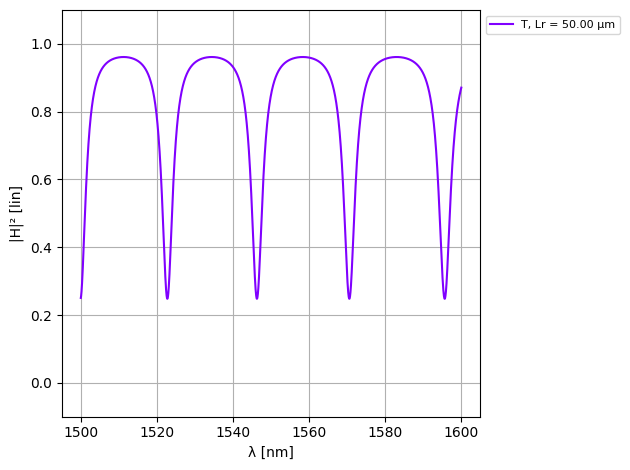

FSR calculation
----------------
Lr = 50.00 um
lambda0 = 1.550 um
ng = 2.00
FSR = lambda0^2 / (ng * Lr)
FSR = 0.024025 um
FSR = 24.025 nm



In [11]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,])

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

# Only one plot: linear scale
fig, ax = plt.subplots(1, 1)

for i, delta_l in enumerate(delta_l_v):
    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={"length": delta_l, "loss": 0.02, "ng": 2},
        coup={"coupling": coupling}
    )

    T = ring_ap_test["in0", "out0"]

    # Linear power transmission
    T_lin = np.abs(T)**2

    # Plot in linear scale
    ax.plot(
        wl * 1e3,
        T_lin,
        linestyle="-",
        color=color[i],
        label=f"T, Lr = {delta_l:.2f} µm"
    )

ax.set_ylim([-0.1, 1.1])
ax.grid(visible=True)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("λ [nm]")
ax.set_ylabel("|H|² [lin]")

plt.tight_layout()
plt.show()

# =========================
# FSR calculation
# =========================

ng = 2
lambda0 = 1.55   # um, central wavelength

for delta_l in delta_l_v:
    Lr = delta_l   # um, ring perimeter

    FSR_um = lambda0**2 / (ng * Lr)
    FSR_nm = FSR_um * 1e3

    print("FSR calculation")
    print("----------------")
    print(f"Lr = {Lr:.2f} um")
    print(f"lambda0 = {lambda0:.3f} um")
    print(f"ng = {ng:.2f}")
    print("FSR = lambda0^2 / (ng * Lr)")
    print(f"FSR = {FSR_um:.6f} um")
    print(f"FSR = {FSR_nm:.3f} nm")
    print()

Then we can test the circuit to check the functionality

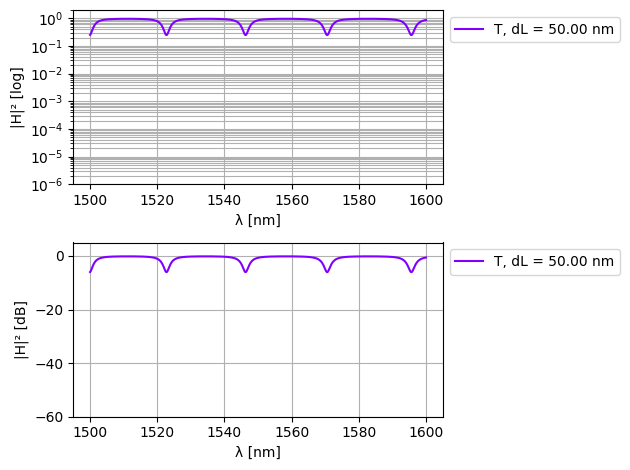

FSR calculation
----------------
Lr = 50.00 um
lambda0 = 1.550 um
ng = 2.00
FSR = lambda0^2 / (ng * Lr)
FSR = 0.024025 um
FSR = 24.025 nm



In [12]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,])

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2, 1)

for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={"length": delta_l, "loss": 0.02, "ng":2},
        coup={"coupling": coupling}
    )

    T = ring_ap_test["in0", "out0"]

    # Linear power transmission
    T_lin = np.abs(T)**2

    # Transmission in dB
    # Equivalent forms:
    # T_dB = 20.0 * jnp.log10(np.abs(T))
    T_dB = 10.0 * jnp.log10(T_lin)

    # Plot in logarithmic scale
    ax[0].plot(
        wl * 1e3,
        T_lin,
        linestyle="-",
        color=color[i],
        label=f"T, dL = {delta_l:.2f} nm"
    )

    # Plot in dB
    ax[1].plot(
        wl * 1e3,
        T_dB,
        linestyle="-",
        color=color[i],
        label=f"T, dL = {delta_l:.2f} nm"
    )

# Logarithmic scale for the linear plot
ax[0].set_yscale("log")
ax[0].set_ylim([1e-6, 2])

# dB plot limits
ax[1].set_ylim([-60, 5])

for i in range(0, 2):
    ax[i].grid(visible=True, which="both")
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc="upper left", bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|² [log]")
ax[1].set_ylabel("|H|² [dB]")

plt.tight_layout()
plt.show()
# =========================
# FSR calculation
# =========================

ng = 2
lambda0 = 1.55   # um, central wavelength

for delta_l in delta_l_v:
    Lr = delta_l   # um, ring perimeter

    FSR_um = lambda0**2 / (ng * Lr)
    FSR_nm = FSR_um * 1e3

    print("FSR calculation")
    print("----------------")
    print(f"Lr = {Lr:.2f} um")
    print(f"lambda0 = {lambda0:.3f} um")
    print(f"ng = {ng:.2f}")
    print("FSR = lambda0^2 / (ng * Lr)")
    print(f"FSR = {FSR_um:.6f} um")
    print(f"FSR = {FSR_nm:.3f} nm")
    print()

#### 1.1.2. Ring coupled to two waveguides

For this design variation, the ring perimeter is divided into two straight sections that connect both couplers

In [13]:
ring_2bus, info = sax.circuit(
    netlist={
        "instances": {
            "wvg_S_in": "waveguide",
            "wvg_S_out": "waveguide",
            "coup_S": "coupler",
            "wvg_ring_E": "waveguide",
            "wvg_ring_W": "waveguide",
            "coup_N": "coupler",
            "wvg_N_in": "waveguide",
            "wvg_N_out": "waveguide",
        },
        "connections": {
            "wvg_S_in,out0": "coup_S,in0",
            "coup_S,out0": "wvg_S_out,in0",
            "coup_S,out1": "wvg_ring_E,in0",
            "wvg_ring_E,out0": "coup_N,in1",
            "coup_N,out1": "wvg_ring_W,in0",
            "wvg_ring_W,out0": "coup_S,in1",
            "wvg_N_in,out0": "coup_N,in0",
            "coup_N,out0": "wvg_N_out,in0",
        },
        "ports": {
            "in0": "wvg_S_in,in0",
            "out0": "wvg_S_out,out0",
            "in1": "wvg_N_in,in0",
            "out1": "wvg_N_out,out0",
        },
    },
    models= {
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

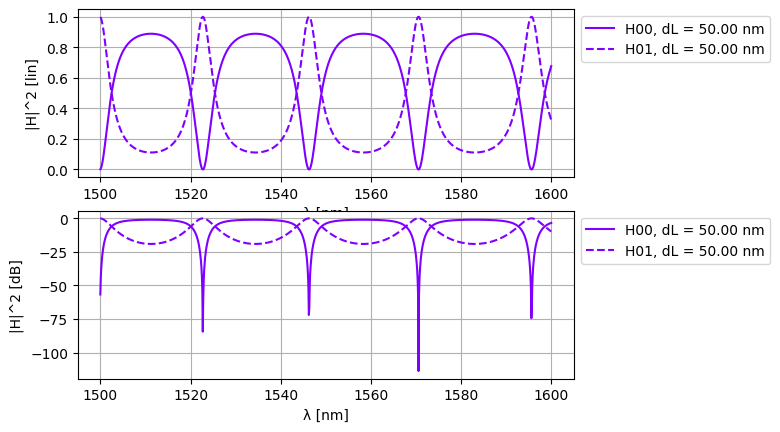

In [14]:
wl = jnp.linspace(1.50, 1.60, 1000)

delta_l_v = np.array([50,]) 

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l, "loss": 2.0}, coup_N={"coupling": 0.0})
    ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l, "ng":2}, wvg_ring_W={"length": 0.5*delta_l, "ng":2})
    H00 = ring_2bus_test["in0", "out0"]
    H01 = ring_2bus_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")


The resulting interference pattern again exhibits a periodic behavior. We define again the **free spectral range** (FSR), which should satisfy in this case the relationship:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,L_r}
$$

Where $L_r$ is the ring perimeter. Note that in our circuit model, we neglect the length of the coupler, so the perimeter is defined by the length of the waveguide sections.

#### **HINT**

You can perform parametric variations using the codes provided by us, for instance, check this casi in which we performed a loss sweep. 

Text(0, 0.5, '|H|^2 [dB]')

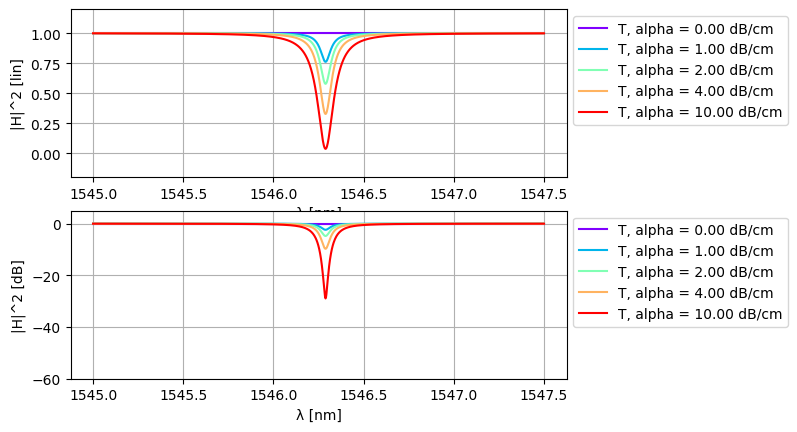

In [15]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a loss sweep
loss_dBum = 1e-4*np.array([0,1,2,4,10])

n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
coupling = 0.025

fig, ax = plt.subplots(2,1)
#Update the variable you enumarate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss, "ng":2, "neff": 1.6072, "wl0": 1.55}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

## LO.5. Ring resonator design

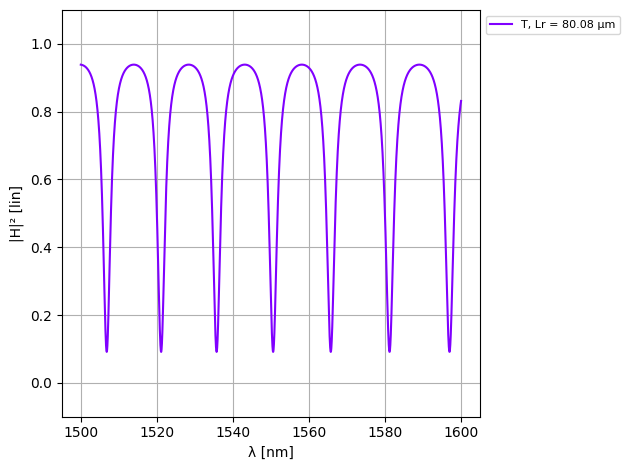

Ring design for FSR = 15 nm
----------------------------
Target FSR = 15.000 nm
lambda0 = 1.550 um
ng = 2.00
Designed Lr = 80.083 um

Check:
FSR = lambda0^2 / (ng * Lr)
FSR = 0.015000 um
FSR = 15.000 nm


In [16]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# =========================
# Design target
# =========================

ng = 2
lambda0 = 1.55          # um
FSR_target_nm = 15      # nm
FSR_target_um = FSR_target_nm * 1e-3   # nm -> um

# Ring perimeter designed for FSR = 15 nm
Lr_design = lambda0**2 / (ng * FSR_target_um)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([Lr_design])

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

# Only one plot: linear scale
fig, ax = plt.subplots(1, 1)

for i, delta_l in enumerate(delta_l_v):

    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": delta_l,
            "loss": 0.02,
            "ng": ng
        },
        coup={"coupling": coupling}
    )

    T = ring_ap_test["in0", "out0"]

    # Linear power transmission
    T_lin = np.abs(T)**2

    # Plot in linear scale
    ax.plot(
        wl * 1e3,
        T_lin,
        linestyle="-",
        color=color[i],
        label=f"T, Lr = {delta_l:.2f} µm"
    )

ax.set_ylim([-0.1, 1.1])
ax.grid(visible=True)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("λ [nm]")
ax.set_ylabel("|H|² [lin]")

plt.tight_layout()
plt.show()

# =========================
# FSR calculation
# =========================

for delta_l in delta_l_v:
    Lr = delta_l   # um, ring perimeter

    FSR_um = lambda0**2 / (ng * Lr)
    FSR_nm = FSR_um * 1e3

    print("Ring design for FSR = 15 nm")
    print("----------------------------")
    print(f"Target FSR = {FSR_target_nm:.3f} nm")
    print(f"lambda0 = {lambda0:.3f} um")
    print(f"ng = {ng:.2f}")
    print(f"Designed Lr = {Lr:.3f} um")
    print()
    print("Check:")
    print("FSR = lambda0^2 / (ng * Lr)")
    print(f"FSR = {FSR_um:.6f} um")
    print(f"FSR = {FSR_nm:.3f} nm")

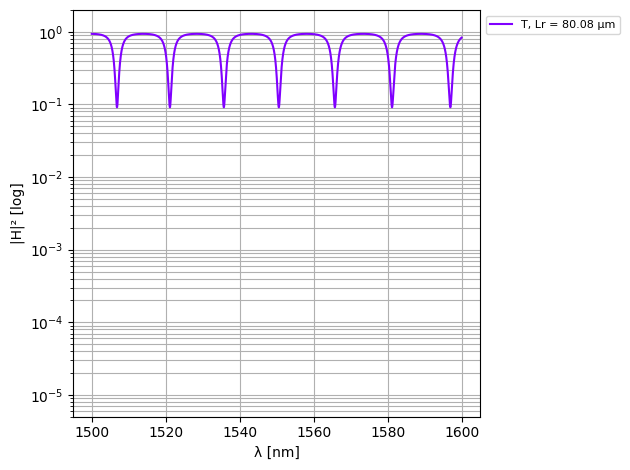

Ring design for FSR = 15 nm
----------------------------
Target FSR = 15.000 nm
lambda0 = 1.550 um
ng = 2.00
Designed Lr = 80.083 um

Check:
FSR = lambda0^2 / (ng * Lr)
FSR = 0.015000 um
FSR = 15.000 nm


In [17]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# =========================
# Design target
# =========================

ng = 2
lambda0 = 1.55          # um
FSR_target_nm = 15      # nm
FSR_target_um = FSR_target_nm * 1e-3   # nm -> um

# Ring perimeter designed for FSR = 15 nm
Lr_design = lambda0**2 / (ng * FSR_target_um)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([Lr_design])

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

# Only one plot: logarithmic scale
fig, ax = plt.subplots(1, 1)

for i, delta_l in enumerate(delta_l_v):

    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": delta_l,
            "loss": 0.02,
            "ng": ng
        },
        coup={"coupling": coupling}
    )

    T = ring_ap_test["in0", "out0"]

    # Linear power transmission
    T_lin = np.abs(T)**2

    # Plot in logarithmic scale
    ax.plot(
        wl * 1e3,
        T_lin,
        linestyle="-",
        color=color[i],
        label=f"T, Lr = {delta_l:.2f} µm"
    )

ax.set_yscale("log")
ax.set_ylim([5e-6, 2])

ax.grid(visible=True, which="both")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
ax.set_xlabel("λ [nm]")
ax.set_ylabel("|H|² [log]")

plt.tight_layout()
plt.show()

# =========================
# FSR calculation
# =========================

for delta_l in delta_l_v:
    Lr = delta_l   # um, ring perimeter

    FSR_um = lambda0**2 / (ng * Lr)
    FSR_nm = FSR_um * 1e3

    print("Ring design for FSR = 15 nm")
    print("----------------------------")
    print(f"Target FSR = {FSR_target_nm:.3f} nm")
    print(f"lambda0 = {lambda0:.3f} um")
    print(f"ng = {ng:.2f}")
    print(f"Designed Lr = {Lr:.3f} um")
    print()
    print("Check:")
    print("FSR = lambda0^2 / (ng * Lr)")
    print(f"FSR = {FSR_um:.6f} um")
    print(f"FSR = {FSR_nm:.3f} nm")

## LO.6.a Effect of K

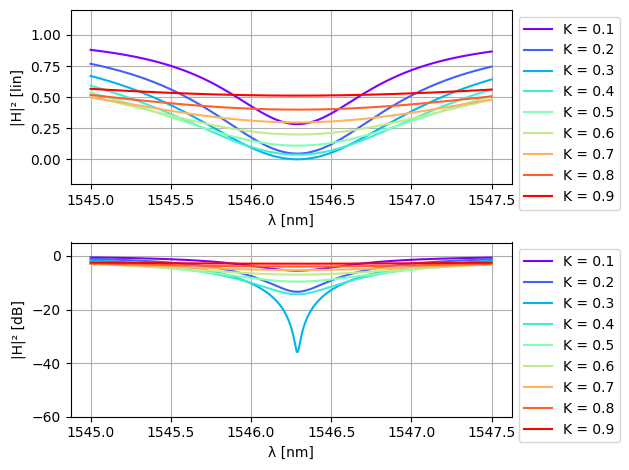

In [18]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a K sweep
coupling_v = np.arange(0.1, 1.0, 0.1)

n_curves = np.shape(coupling_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
loss = 0.02

fig, ax = plt.subplots(2, 1)

# Update the variable you enumerate below
for i, coupling in enumerate(coupling_v):

    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(
        wl=wl,
        wvg_ring={
            "length": ring_perimeter,
            "loss": 0.02,
            "ng": 2,
            "neff": 1.6072,
            "wl0": 1.55
        },
        coup={
            "coupling": coupling
        }
    )

    T = ring_ap_test["in0", "out0"]

    T_lin = np.abs(T)**2

    # dB
    T_dB = 10.0*jnp.log10(T_lin)
    # Equivalent:
    # T_dB = 20.0*jnp.log10(np.abs(T))

    ax[0].plot(
        wl * 1e3,
        T_lin,
        linestyle="-",
        color=color[i],
        label=f"K = {coupling:.1f}"
    )

    ax[1].plot(
        wl * 1e3,
        T_dB,
        linestyle="-",
        color=color[i],
        label=f"K = {coupling:.1f}"
    )

ax[0].set_ylim([-0.2, 1.2])

for i in range(0, 2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc="upper left", bbox_to_anchor=(1, 1))

ax[1].set_ylim([-60, 5])

ax[0].set_ylabel("|H|² [lin]")
ax[1].set_ylabel("|H|² [dB]")

plt.tight_layout()
plt.show()

Text(0, 0.5, '|H|^2 [dB]')

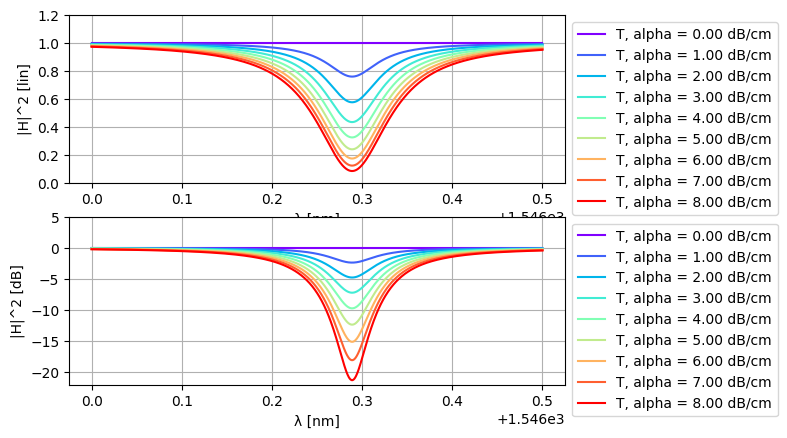

In [19]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.546, 1.5465, 1000)
 
# Now we perform a loss sweep
loss_dBum = 1e-4*np.array([0,1,2,3,4,5,6,7,8,])
 
n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))
 
ring_perimeter = 75.0
coupling = 0.025
 
fig, ax = plt.subplots(2,1)
#Update the variable you enumarate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]
 
    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)
 
    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")
 
    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")
 
ax[0].set_ylim([0,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-22,5])
 
ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

Now use this code section to obtain the results of LOs4, 5, and 6.